In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
from scipy.io import loadmat
import pandas as pd
import numpy as np
import mne
import os
from sklearn.model_selection import GridSearchCV, train_test_split
from mne.decoding import CSP
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, cohen_kappa_score

In [2]:
file_data = loadmat('Data Session 1/david_20200206_session1.mat')
data = file_data['data']
data

array([[ -0.53112405, -10.69164375,  -9.89476476, ...,   0.03817907,
          0.05972909,   0.        ],
       [  1.57066337,  -9.68108756,  -8.47274879, ...,   0.21401706,
         -0.07736803,   0.        ],
       [  3.39664058,  -8.77180474,  -7.19927289, ...,   0.3756561 ,
         -0.20167547,   0.        ],
       ...,
       [  5.11733635,   6.5928892 ,   7.7642441 , ...,   0.72400476,
         -0.32312942,   0.        ],
       [  3.89598968,   4.96861396,   5.97299035, ...,   0.57882078,
         -0.28092453,   0.        ],
       [  2.68955313,   3.40410196,   4.16799709, ...,   0.41752655,
         -0.21373552,   0.        ]])

In [3]:
cols = np.arange(73)
columns = []
[columns.append(str(x)) for x in cols]
columns

['0',
 '1',
 '2',
 '3',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 '10',
 '11',
 '12',
 '13',
 '14',
 '15',
 '16',
 '17',
 '18',
 '19',
 '20',
 '21',
 '22',
 '23',
 '24',
 '25',
 '26',
 '27',
 '28',
 '29',
 '30',
 '31',
 '32',
 '33',
 '34',
 '35',
 '36',
 '37',
 '38',
 '39',
 '40',
 '41',
 '42',
 '43',
 '44',
 '45',
 '46',
 '47',
 '48',
 '49',
 '50',
 '51',
 '52',
 '53',
 '54',
 '55',
 '56',
 '57',
 '58',
 '59',
 '60',
 '61',
 '62',
 '63',
 '64',
 '65',
 '66',
 '67',
 '68',
 '69',
 '70',
 '71',
 '72']

In [4]:
df = pd.DataFrame(data, columns=columns)
df

,0,1,2,3,4,5,6,7,8,9,...,63,64,65,66,67,68,69,70,71,72
0,-0.531124,-10.691644,-9.894765,-21.620727,-5.189152,-33.038164,-6.986326,-18.379200,-4.669138,-1.971644,...,-3.354946,3.250825,-0.507105,-0.469683,0.024723,0.239535,-0.020935,0.038179,0.059729,0.0
1,1.570663,-9.681088,-8.472749,-21.749539,-3.828494,-33.425938,-7.725906,-18.075198,-3.796731,-1.603915,...,-5.952251,4.087477,3.398171,-0.119125,0.658501,0.187099,-0.027694,0.214017,-0.077368,0.0
2,3.396641,-8.771805,-7.199273,-21.822957,-2.572791,-33.645889,-8.363120,-17.885851,-3.157735,-1.425326,...,-8.451885,4.738344,7.138064,0.206791,1.202919,0.138467,-0.044328,0.375656,-0.201675,0.0
3,4.766117,-8.042875,-6.191671,-21.864715,-1.533393,-33.618895,-8.823382,-17.850508,-2.881101,-1.524979,...,-10.717637,5.106279,10.299525,0.477411,1.599815,0.107061,-0.067877,0.513331,-0.305841,0.0
4,5.597877,-7.547468,-5.520046,-21.884661,-0.785252,-33.325643,-9.105738,-18.007377,-3.038385,-1.915336,...,-12.635287,5.045196,12.669098,0.681520,1.827277,0.098201,-0.089777,0.623272,-0.387475,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
841211,6.831581,9.020207,10.309655,5.575536,5.871644,-0.200968,2.927445,1.692424,12.641076,4.978758,...,-12.871791,1.847851,1.950297,0.935559,0.343743,-0.718096,-1.207915,0.914434,-0.302015,0.0
841212,6.156846,8.023604,9.284277,5.616035,5.816230,0.356072,1.915472,0.693528,10.706088,4.877544,...,-11.163415,2.393544,2.746830,0.799083,0.328020,-0.648483,-1.157011,0.838572,-0.331355,0.0
841213,5.117336,6.592889,7.764244,5.139296,5.182175,0.529962,0.866667,-0.249318,8.413025,4.278260,...,-9.145273,2.579375,3.035114,0.637816,0.296498,-0.556926,-1.047237,0.724005,-0.323129,0.0
841214,3.895990,4.968614,5.972990,4.252964,4.161722,0.477698,0.061557,-0.862776,6.090175,3.378021,...,-6.977364,2.390495,2.832001,0.471185,0.247771,-0.445800,-0.874993,0.578821,-0.280925,0.0


In [5]:
df = df.drop(['67','68','69','70','71'], axis=1)
df

,0,1,2,3,4,5,6,7,8,9,...,58,59,60,61,62,63,64,65,66,72
0,-0.531124,-10.691644,-9.894765,-21.620727,-5.189152,-33.038164,-6.986326,-18.379200,-4.669138,-1.971644,...,-8.485180,-12.202755,-15.568504,-13.246663,-3.172073,-3.354946,3.250825,-0.507105,-0.469683,0.0
1,1.570663,-9.681088,-8.472749,-21.749539,-3.828494,-33.425938,-7.725906,-18.075198,-3.796731,-1.603915,...,-8.328539,-13.084729,-16.223833,-15.586484,-2.863474,-5.952251,4.087477,3.398171,-0.119125,0.0
2,3.396641,-8.771805,-7.199273,-21.822957,-2.572791,-33.645889,-8.363120,-17.885851,-3.157735,-1.425326,...,-8.273426,-13.923490,-16.844381,-17.858632,-2.691542,-8.451885,4.738344,7.138064,0.206791,0.0
3,4.766117,-8.042875,-6.191671,-21.864715,-1.533393,-33.618895,-8.823382,-17.850508,-2.881101,-1.524979,...,-8.430324,-14.736967,-17.435367,-19.962027,-2.723767,-10.717637,5.106279,10.299525,0.477411,0.0
4,5.597877,-7.547468,-5.520046,-21.884661,-0.785252,-33.325643,-9.105738,-18.007377,-3.038385,-1.915336,...,-8.828392,-15.522832,-18.005709,-21.796352,-2.984838,-12.635287,5.045196,12.669098,0.681520,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
841211,6.831581,9.020207,10.309655,5.575536,5.871644,-0.200968,2.927445,1.692424,12.641076,4.978758,...,-6.063890,-8.167773,-18.651337,-11.559410,-8.477101,-12.871791,1.847851,1.950297,0.935559,0.0
841212,6.156846,8.023604,9.284277,5.616035,5.816230,0.356072,1.915472,0.693528,10.706088,4.877544,...,-4.727477,-6.321022,-16.342419,-9.676608,-7.097924,-11.163415,2.393544,2.746830,0.799083,0.0
841213,5.117336,6.592889,7.764244,5.139296,5.182175,0.529962,0.866667,-0.249318,8.413025,4.278260,...,-3.418812,-4.501386,-13.578978,-7.625505,-5.643569,-9.145273,2.579375,3.035114,0.637816,0.0
841214,3.895990,4.968614,5.972990,4.252964,4.161722,0.477698,0.061557,-0.862776,6.090175,3.378021,...,-2.274376,-2.922910,-10.523870,-5.593314,-4.202351,-6.977364,2.390495,2.832001,0.471185,0.0


In [6]:
columns.remove('67')
columns.remove('68')
columns.remove('69')
columns.remove('70')
columns.remove('71')

In [7]:
sfreq = 512
info = mne.create_info(ch_names=columns, sfreq=sfreq, ch_types='eeg')

Creating RawArray with float64 data, n_channels=68, n_times=841216
    Range : 0 ... 841215 =      0.000 ...  1642.998 secs
Ready.


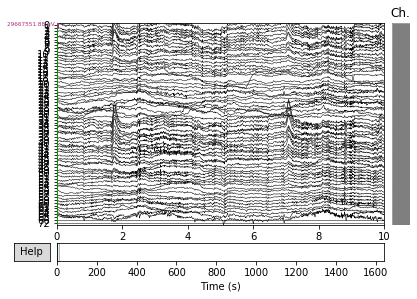

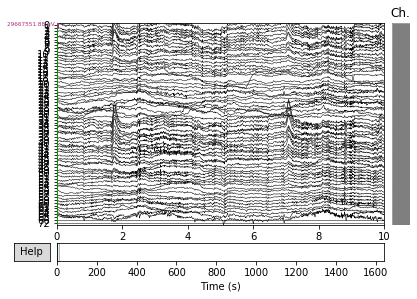

In [8]:
raw = mne.io.RawArray(df.T, info)
scalings = 'auto'
raw.plot(n_channels=68, scalings=scalings, title='Auto-scaled Data from arrays',
         show=True, block=True)

In [9]:
event_dict = {'Long/Hands': 1, 'Relax': 4}

In [10]:
events = mne.find_events(raw, stim_channel='72')
print(events[:5])  # show the first 5

96 events found
Event IDs: [1 4]
[[ 93178      0      4]
 [ 98647      0      1]
 [104046      0      4]
 [109447      0      1]
 [114854      0      4]]


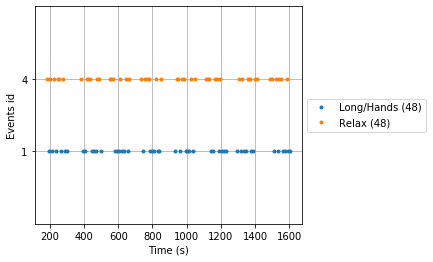

In [11]:
fig = mne.viz.plot_events(events, event_id=event_dict, sfreq=raw.info['sfreq'])
fig.subplots_adjust(right=0.7)  # make room for the legend

In [12]:
fig.savefig('2_class_events.pdf')

In [13]:
epochs = mne.Epochs(raw, events, event_id=event_dict, tmin=-0.1, tmax=2
                    , preload=True)

96 matching events found
Applying baseline correction (mode: mean)
Not setting metadata
0 projection items activated
Loading data for 96 events and 1076 original time points ...
0 bad epochs dropped


In [14]:
labels = epochs.events[:, -1]
epochs_data = epochs.get_data()

In [15]:
X_train, X_test, y_train, y_test = train_test_split(epochs_data, labels, test_size=0.2, random_state=42)

In [16]:
csp = CSP(n_components=4, reg=None, log=True, norm_trace=False)

In [17]:
X_train_csp = csp.fit_transform(X_train, y_train)

Computing data rank from raw with rank=None
    Using tolerance 3.4e+02 (2.2e-16 eps * 68 dim * 2.3e+16  max singular value)
    Estimated rank (mag): 68
    MAG: rank 68 computed from 68 data channels with 0 projectors
Reducing data rank from 68 -> 68
Estimating covariance using EMPIRICAL
Done.
Computing data rank from raw with rank=None
    Using tolerance 2.7e+02 (2.2e-16 eps * 68 dim * 1.8e+16  max singular value)
    Estimated rank (mag): 68
    MAG: rank 68 computed from 68 data channels with 0 projectors
Reducing data rank from 68 -> 68
Estimating covariance using EMPIRICAL
Done.


In [18]:
X_test_csp = csp.transform(X_test)

In [19]:
param = {'C' : [ 0.1, 1, 10, 50, 100, 1000], 'gamma': [1, 0.1, 0.01, 0.001, 0.0001], 'kernel': ['rbf', 'linear']}
svm = SVC()

In [20]:
grid = GridSearchCV(svm, param, cv=10, scoring='accuracy', return_train_score=True, verbose=1)

In [21]:
grid.fit(X_train_csp, y_train)

Fitting 10 folds for each of 60 candidates, totalling 600 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done 600 out of 600 | elapsed:    1.2s finished
/home/rohit/anaconda3/lib/python3.7/site-packages/sklearn/model_selection/_search.py:814: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be removed in 0.24. This will change numeric results when test-set sizes are unequal.
  DeprecationWarning)


GridSearchCV(cv=10, error_score='raise-deprecating',
             estimator=SVC(C=1.0, cache_size=200, class_weight=None, coef0=0.0,
                           decision_function_shape='ovr', degree=3,
                           gamma='auto_deprecated', kernel='rbf', max_iter=-1,
                           probability=False, random_state=None, shrinking=True,
                           tol=0.001, verbose=False),
             iid='warn', n_jobs=None,
             param_grid={'C': [0.1, 1, 10, 50, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf', 'linear']},
             pre_dispatch='2*n_jobs', refit=True, return_train_score=True,
             scoring='accuracy', verbose=1)

In [22]:
print(grid.best_params_)
print(grid.best_estimator_)

{'C': 0.1, 'gamma': 1, 'kernel': 'linear'}
SVC(C=0.1, cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma=1, kernel='linear',
    max_iter=-1, probability=False, random_state=None, shrinking=True,
    tol=0.001, verbose=False)


In [23]:
y_pred = grid.predict(X_test_csp)

In [24]:
print(accuracy_score(y_test, y_pred))
print(cohen_kappa_score(y_test, y_pred))

1.0
1.0


In [25]:
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier()
dummy.fit(X_train_csp, y_train)
dummy_pred = dummy.predict(X_test_csp)
print(accuracy_score(y_test, dummy_pred))
print(cohen_kappa_score(y_test, dummy_pred))

0.6
0.22330097087378642


In [30]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
param = {'solver' : ['lsqr', 'eigen'], 'shrinkage' : [None, 'auto']}
lda = LinearDiscriminantAnalysis()

grid = GridSearchCV(lda, param, cv=15, scoring='accuracy', return_train_score=True, verbose=1)
grid.fit(X_train_csp, y_train)

Fitting 15 folds for each of 4 candidates, totalling 60 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done  60 out of  60 | elapsed:    0.2s finished


GridSearchCV(cv=15, error_score='raise-deprecating',
             estimator=LinearDiscriminantAnalysis(n_components=None,
                                                  priors=None, shrinkage=None,
                                                  solver='svd',
                                                  store_covariance=False,
                                                  tol=0.0001),
             iid='warn', n_jobs=None,
             param_grid={'shrinkage': [None, 'auto'],
                         'solver': ['lsqr', 'eigen']},
             pre_dispatch='2*n_jobs', refit=True, return_train_score=True,
             scoring='accuracy', verbose=1)

In [31]:
y_pred = grid.predict(X_test_csp)
print(accuracy_score(y_test, y_pred))
print(cohen_kappa_score(y_test, y_pred))

1.0
1.0


In [25]:
### Trying CV with pipelining

from sklearn.pipeline import Pipeline
from sklearn.model_selection import ShuffleSplit, cross_val_score

cv = ShuffleSplit(10, test_size=0.2, random_state=42)
# cv_split = cv.split(epochs_data)

# Assemble a classifier
svm = SVC(C=0.1, gamma=1, kernel='linear')
csp = CSP(n_components=4, reg=None, log=True, norm_trace=False)

# Use scikit-learn Pipeline with cross_val_score function
clf = Pipeline([('CSP', csp), ('SVM', svm)])
scores = cross_val_score(clf, epochs_data, labels, cv=cv, n_jobs=1)

Computing data rank from raw with rank=None
    Using tolerance 3.4e+02 (2.2e-16 eps * 68 dim * 2.3e+16  max singular value)
    Estimated rank (mag): 68
    MAG: rank 68 computed from 68 data channels with 0 projectors
Reducing data rank from 68 -> 68
Estimating covariance using EMPIRICAL
Done.
Computing data rank from raw with rank=None
    Using tolerance 2.7e+02 (2.2e-16 eps * 68 dim * 1.8e+16  max singular value)
    Estimated rank (mag): 68
    MAG: rank 68 computed from 68 data channels with 0 projectors
Reducing data rank from 68 -> 68
Estimating covariance using EMPIRICAL
Done.
Computing data rank from raw with rank=None
    Using tolerance 2.7e+02 (2.2e-16 eps * 68 dim * 1.8e+16  max singular value)
    Estimated rank (mag): 68
    MAG: rank 68 computed from 68 data channels with 0 projectors
Reducing data rank from 68 -> 68
Estimating covariance using EMPIRICAL
Done.
Computing data rank from raw with rank=None
    Using tolerance 2.8e+02 (2.2e-16 eps * 68 dim * 1.9e+16  max 

In [26]:
print('Classification Accuracy: ', np.mean(scores))

Classification Accuracy:  0.9949999999999999
